<a href="https://colab.research.google.com/github/karunashakar07042021-arch/Social-Media-Engagement-Analytics/blob/main/Social_Media_Engagement_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Assignment Tasks

####	❖  Task 1 — Data Import & Setup

In [ ]:
# Import CSV using Pandas
import pandas as pd
df = pd.read_csv("https://github.com/GeethaGunasekaran1/Dataset_rep/raw/refs/heads/main/social_media_engagement_5000.csv")
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [ ]:
# Check/convert data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
# Convert date columns to datetime

df["posted_at"]  = pd.to_datetime(df["posted_at"])
df["posted_at"].dtype


dtype('<M8[ns]')

#####  ❖	Task 2 — Data Cleaning

In [ ]:
# Cleaning Missing Data
# Detect missing values (isnull(), isna())
# Handle using: dropna(), fillna(), median/mode, forward/backward-fill

In [ ]:
df.isnull().sum()

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

In [ ]:
df.isna()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().mean()*100

user_id             0.0
age                 3.0
gender              3.0
country             0.0
post_id             0.0
post_type           0.0
post_category       0.0
likes               3.0
comments            3.0
shares              3.0
watch_time_sec      0.0
impression_count    0.0
posted_at           0.0
follower_count      0.0
is_verified         0.0
device_type         0.0
sentiment           3.0
hashtags            0.0
engagement_rate     0.0
dtype: float64

In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate
count,5000.000000,4850.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348
std,26090.370121,14.912381,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,NaN,230927.884535,5.318029


In [ ]:
df.describe(include = "object")

,gender,country,post_type,post_category,posted_at,device_type,sentiment,hashtags
count,4850,5000,5000,5000,5000,5000,4850,5000
unique,3,10,4,8,729,3,3,761
top,Male,India,reel,fitness,26-12-2023,mobile,positive,#tech
freq,1699,535,1283,675,16,1684,2363,201


In [ ]:
numerical_column = df.select_dtypes(include = "number").columns
print("The numerical columns name : \n",numerical_column)


The numerical columns name : 
 Index(['user_id', 'age', 'post_id', 'likes', 'comments', 'shares',
       'watch_time_sec', 'impression_count', 'follower_count',
       'engagement_rate'],
      dtype='object')


In [ ]:
exclude_cols = df[["likes", "impression_count"]]

# Select numerical columns except excluded ones
num_cols = [col for col in df.columns
            if col in numerical_column and col not in exclude_cols]

# Fill NaN with mean for each selected column
df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.mean()))


In [ ]:
df["likes"] = df["likes"].fillna(df["likes"].median())
df["impression_count"] = df["impression_count"].fillna(df["impression_count"].median())

In [ ]:
categorial_coulmn = df.select_dtypes(include =  "object").columns
print("The categorical columns name : \n",categorial_coulmn)

The categorical columns name : 
 Index(['gender', 'country', 'post_type', 'post_category', 'device_type',
       'sentiment', 'hashtags'],
      dtype='object')


In [ ]:
CA_col  = df[categorial_coulmn].mode().iloc[0]
df[categorial_coulmn] = df[categorial_coulmn].fillna(CA_col)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64

In [ ]:
# Duplicate Handling- Identify & remove duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.00000,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.00000,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.00000,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.00000,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.00000,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.00000,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.00000,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.00000,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [ ]:
# Data Formatting
# Fix incorrect data types
# Standardize categories (e.g., gender labels)

df["gender"] = df["gender"].str.title()
df["country"] = df["country"].str.title()
df["device_type"] = df["device_type"].str.title()
# Correct unrealistic values in likes, comments, shares
df = df[df["likes"] >= 0]
df = df[df["comments"] >= 0]
df = df[df["shares"] >= 0]

In [ ]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.00000,1157.0,5726,44650,2022-12-17,81734,False,Mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.00000,1807.0,5947,80216,2023-06-02,5963,False,Mobile,negative,#fitness,0.201493
2,86820,32.0,Female,Uk,109864,text,food,4862.0,344.00000,955.0,6946,44858,2023-05-07,501783,False,Tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.00000,1049.0,229,70455,2023-02-12,480212,False,Mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,Uk,449706,image,fitness,12682.0,2735.00000,1300.0,4798,6019,2023-05-23,383936,False,Mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.00000,1837.0,6190,42977,2022-06-25,646147,False,Mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,Uae,677076,reel,education,16924.0,2734.00000,1583.0,7764,34196,2022-11-18,584603,False,Desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,Usa,273595,text,travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,Desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.00000,1713.0,4991,89013,2022-05-16,183295,False,Tablet,positive,#reels #love #fitness,0.223518


In [ ]:
# Feature Cleaning
df["post_type"] = df["post_type"].str.title()
df["post_category"] = df["post_category"].str.title()

df["age"] = df["age"].astype(int)
# Extract hashtag count
df["hashtag_count"] = df["hashtags"].apply(lambda x: len(str(x).split()))
df["hashtag_Extract"] = df["hashtags"].str.replace('#', '', regex=False)
df["hashtag_Extract"] = df["hashtag_Extract"].str.title()
# Clean sentiment labels
df["sentiment"] = df["sentiment"].str.title()


In [ ]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,engagement_score,hashtag_count,hashtag_Extract
0,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.00000,1157.0,...,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,8522.00000,3,Foodie Travel Love
1,10860,33,Male,Brazil,157326,Reel,Food,11750.0,2606.00000,1807.0,...,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493,16163.00000,1,Fitness
2,86820,32,Female,Uk,109864,Text,Food,4862.0,344.00000,955.0,...,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345,6161.00000,1,Foodie
3,64886,51,Other,France,848877,Text,Fitness,5350.0,1083.00000,1049.0,...,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,7482.00000,3,Music Foodie Fun
4,16265,34,Other,Uk,449706,Image,Fitness,12682.0,2735.00000,1300.0,...,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372,16717.00000,1,Travel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,Male,Australia,441541,Video,Education,16210.0,2013.00000,1837.0,...,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761,20060.00000,2,Travel Fun
4996,22100,38,Other,Uae,677076,Reel,Education,16924.0,2734.00000,1583.0,...,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155,21241.00000,2,Foodie Reels
4997,67021,63,Female,Usa,273595,Text,Travel,13487.0,1502.19567,167.0,...,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688,15156.19567,2,Lifestyle Tech
4998,29800,13,Female,Germany,785644,Video,Fitness,16894.0,1289.00000,1713.0,...,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518,19896.00000,3,Reels Love Fitness


#### ❖	Task 3 — Data Exploration using Pandas

In [ ]:
# View dataset structure using head(), tail(), shape, and columns.


In [ ]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,Mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,Mobile,negative,#fitness,0.201493
2,86820,32.0,Female,Uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,Tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,Mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,Uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,Mobile,negative,#travel,2.777372


In [ ]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.00000,1837.0,6190,42977,2022-06-25,646147,False,Mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,Uae,677076,reel,education,16924.0,2734.00000,1583.0,7764,34196,2022-11-18,584603,False,Desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,Usa,273595,text,travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,Desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.00000,1713.0,4991,89013,2022-05-16,183295,False,Tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.00000,1798.0,3743,14234,2023-03-04,585760,False,Desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [ ]:
df.shape

(5000, 19)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [ ]:
#	Check data types and info with info() and dtypes.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
df.dtypes

user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
dtype: object

In [ ]:
#	Generate summary statistics using describe().
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.195670,1002.629485,4014.503200,50013.732800,393698.224800,0.964356,1.998600
std,26090.370121,14.687151,260646.957267,5702.293017,856.392853,570.852962,2308.096459,28844.939104,230927.884535,5.318029,0.812853
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.000000,2017.750000,24988.250000,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1502.195670,1002.629485,4034.500000,49934.500000,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.000000,6020.250000,74662.250000,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,799533.000000,191.504348,3.000000


In [ ]:
# Analyze categorical distributions using value_counts(), unique(), and nunique().
df["gender"].value_counts()


gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

In [ ]:
df["country"].nunique()

10

In [ ]:
df["device_type"].unique()

array(['Mobile', 'Tablet', 'Desktop'], dtype=object)

In [ ]:
# Create a correlation matrix for numeric fields.
df.corr(numeric_only=True)

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate
user_id,1.000000,-0.006680,0.020051,0.025811,-0.033374,0.013785,-0.016847,0.015326,0.010124,0.004058,-0.004282
age,-0.006680,1.000000,-0.013156,-0.036241,-0.007254,0.013900,0.005592,0.013288,-0.025029,-0.000110,0.008023
post_id,0.020051,-0.013156,1.000000,0.014526,-0.010542,0.001873,0.018374,-0.007709,-0.002844,0.025208,0.010139
likes,0.025811,-0.036241,0.014526,1.000000,-0.018425,0.004652,0.008710,0.007952,-0.022982,-0.016200,0.093520
comments,-0.033374,-0.007254,-0.010542,-0.018425,1.000000,0.006130,-0.016346,-0.009392,-0.011742,-0.012404,0.000045
shares,0.013785,0.013900,0.001873,0.004652,0.006130,1.000000,0.014671,-0.005094,-0.010741,0.007086,0.021729
watch_time_sec,-0.016847,0.005592,0.018374,0.008710,-0.016346,0.014671,1.000000,-0.004335,0.002761,0.012326,-0.001148
impression_count,0.015326,0.013288,-0.007709,0.007952,-0.009392,-0.005094,-0.004335,1.000000,-0.015513,0.008317,-0.232226
follower_count,0.010124,-0.025029,-0.002844,-0.022982,-0.011742,-0.010741,0.002761,-0.015513,1.000000,-0.017808,0.002292
is_verified,0.004058,-0.000110,0.025208,-0.016200,-0.012404,0.007086,0.012326,0.008317,-0.017808,1.000000,0.005528


In [ ]:
# Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country)
df.groupby("post_type")["likes"].mean()

post_type
image    10104.865277
reel     10037.802416
text     10100.148193
video    10188.600000
Name: likes, dtype: float64

In [ ]:
df.groupby("country")["impression_count"].mean()

country
Australia    48346.383367
Brazil       49193.174603
Canada       48703.150097
France       51727.673387
Germany      48605.406122
India        52462.386916
Japan        49616.135593
Uae          48928.413519
Uk           51119.393509
Usa          51263.872255
Name: impression_count, dtype: float64

In [ ]:
df.groupby("gender")["likes"].mean()

gender
Female     9998.538217
Male      10345.590590
Other      9935.664137
Name: likes, dtype: float64

In [ ]:
df.groupby("device_type")["impression_count"].mean()

device_type
Desktop    50934.068758
Mobile     49516.948931
Tablet     49597.971049
Name: impression_count, dtype: float64

#### ❖	Task 4 — Data Wrangling

In [ ]:
# Use merge, concat, or join if combining DataFrames
df_self_join = df.join(
    df.set_index('country'),
    on='country',
    rsuffix='_second'
)

df_self_join.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count_second,posted_at_second,follower_count_second,is_verified_second,device_type_second,sentiment_second,hashtags_second,engagement_rate_second,hashtag_count_second,hashtag_Extract_second
0,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,...,44650,17-12-2022,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,3,Foodie Travel Love
0,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,...,80216,02-06-2023,5963,False,Mobile,Negative,#fitness,0.201493,1,Fitness
0,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,...,389,29-10-2023,51929,False,Desktop,Positive,#foodie #lifestyle,48.894602,2,Foodie Lifestyle
0,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,...,86850,11-08-2023,519435,True,Desktop,Positive,#love #music,0.033874,2,Love Music
0,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,...,24240,23-03-2022,148086,False,Mobile,Negative,#travel #fashion #reels,0.545380,3,Travel Fashion Reels


In [ ]:
df_self_merge = pd.merge(
    df,
    df,
    on="post_category",
    suffixes=("_post1", "_post2")
)

df_self_merge.head()

,user_id_post1,age_post1,gender_post1,country_post1,post_id_post1,post_type_post1,post_category,likes_post1,comments_post1,shares_post1,...,impression_count_post2,posted_at_post2,follower_count_post2,is_verified_post2,device_type_post2,sentiment_post2,hashtags_post2,engagement_rate_post2,hashtag_count_post2,hashtag_Extract_post2
0,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,...,44650,17-12-2022,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,3,Foodie Travel Love
1,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,...,70455,12-02-2023,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,3,Music Foodie Fun
2,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,...,6019,23-05-2023,383936,False,Mobile,Negative,#travel,2.777372,1,Travel
3,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,...,17019,14-11-2022,665397,False,Mobile,Positive,#foodie #fitness,0.628474,2,Foodie Fitness
4,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,...,85311,15-08-2023,694794,False,Mobile,Positive,#fun,0.059559,1,Fun


In [ ]:
df_concat_vertical = pd.concat([df, df], axis=0)

df_concat_vertical.shape

(10000, 21)

In [ ]:
df_concat_horizontal = pd.concat([df, df], axis=1)

df_concat_horizontal.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,hashtag_Extract
0,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,...,44650,17-12-2022,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,3,Foodie Travel Love
1,10860,33,Male,Brazil,157326,Reel,Food,11750.0,2606.0,1807.0,...,80216,02-06-2023,5963,False,Mobile,Negative,#fitness,0.201493,1,Fitness
2,86820,32,Female,Uk,109864,Text,Food,4862.0,344.0,955.0,...,44858,07-05-2023,501783,False,Tablet,Positive,#foodie,0.137345,1,Foodie
3,64886,51,Other,France,848877,Text,Fitness,5350.0,1083.0,1049.0,...,70455,12-02-2023,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,3,Music Foodie Fun
4,16265,34,Other,Uk,449706,Image,Fitness,12682.0,2735.0,1300.0,...,6019,23-05-2023,383936,False,Mobile,Negative,#travel,2.777372,1,Travel


In [ ]:
# Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag count.
df["engagement_score"] = df["likes"] + df["comments"] + df["shares"]
df["engagement_score"]

0        8522.00000
1       16163.00000
2        6161.00000
3        7482.00000
4       16717.00000
           ...     
4995    20060.00000
4996    21241.00000
4997    15156.19567
4998    19896.00000
4999    17131.00000
Name: engagement_score, Length: 5000, dtype: float64

In [ ]:
df["hashtag_count"] = df["hashtags"].apply(lambda x: len(str(x).split()))
sample = df[["hashtags", "hashtag_count"]].head()
print(sample.to_string(index=False))

             hashtags  hashtag_count
#foodie #travel #love              3
             #fitness              1
              #foodie              1
  #music #foodie #fun              3
              #travel              1


In [ ]:
df["log_likes"] = np.log1p(df["likes"])
df["log_likes"]

0       8.855378
1       9.371694
2       8.489411
3       8.585039
4       9.448018
          ...   
4995    9.693445
4996    9.736547
4997    9.509556
4998    9.734773
4999    9.604475
Name: log_likes, Length: 5000, dtype: float64

In [ ]:
# Perform groupby summaries by post_type, country, and sentiment
df.groupby("post_type")["engagement_score"].sum()

post_type
Image    1.577365e+07
Reel     1.606819e+07
Text     1.570332e+07
Video    1.551395e+07
Name: engagement_score, dtype: float64

In [ ]:
df.groupby("country")["engagement_rate"].sum()

country
Australia    652.898976
Brazil       776.514714
Canada       470.245906
France       568.615374
Germany      371.909827
India        350.427697
Japan        363.261945
Uae          559.512993
Uk           419.526029
Usa          288.866687
Name: engagement_rate, dtype: float64

In [ ]:
df.groupby("sentiment")["engagement_score"].sum()

sentiment
Negative    1.222214e+07
Neutral     1.900818e+07
Positive    3.182879e+07
Name: engagement_score, dtype: float64

In [ ]:
df.groupby('sentiment')[['likes','comments','shares','engagement_rate']].mean()

,likes,comments,shares,engagement_rate
sentiment,,,,
negative,10208.096875,1516.224683,1007.073029,1.038486
neutral,9923.194499,1528.543564,996.319698,0.991170
positive,10180.062077,1480.826356,1004.766071,0.919744


#### ❖	Task 5 — Statistical Analysis

In [ ]:
# Compute descriptive stats for “likes, comments, shares, watch_time, engagement_rate, followers” columns:

In [ ]:
agg_value  = df.agg({
    "likes":"mean",
    "comments": lambda x: x.mode()[0],
    "shares":"min",
    "follower_count":"sum",
    "watch_time_sec":"max",
    "engagement_rate":"median"

})
agg_value

likes              1.010700e+04
comments           1.502196e+03
shares             0.000000e+00
follower_count     1.968491e+09
watch_time_sec     7.998000e+03
engagement_rate    2.538959e-01
dtype: float64

In [ ]:
# Mean
df.mean(numeric_only=True)

user_id              54561.890800
age                     38.440400
post_id             548042.909000
likes                10106.997400
comments              1502.195670
shares                1002.629485
watch_time_sec        4014.503200
impression_count     50013.732800
follower_count      393698.224800
is_verified              0.096600
engagement_rate          0.964356
hashtag_count            1.998600
engagement_score     12611.822555
log_likes                8.932956
dtype: float64

In [ ]:
# Median
df.median(numeric_only=True)

user_id              54374.500000
age                     38.000000
post_id             548077.500000
likes                10105.500000
comments              1502.195670
shares                1002.629485
watch_time_sec        4034.500000
impression_count     49934.500000
follower_count      388982.000000
is_verified              0.000000
engagement_rate          0.253896
hashtag_count            2.000000
engagement_score     12551.750000
log_likes                9.220934
dtype: float64

In [ ]:
# Mode
df.mode(numeric_only=True)

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate,hashtag_count,engagement_score,log_likes
0,19435.0,38.0,301157.0,10105.5,1502.19567,1002.629485,916.0,24207.0,497502.0,False,0.006363,2.0,15245.0,9.220934
1,56163.0,NaN,444417.0,NaN,NaN,NaN,2145.0,64240.0,NaN,NaN,0.007420,NaN,21623.0,NaN
2,74925.0,NaN,448492.0,NaN,NaN,NaN,4360.0,72211.0,NaN,NaN,0.012676,NaN,NaN,NaN
3,NaN,NaN,457659.0,NaN,NaN,NaN,7003.0,96712.0,NaN,NaN,0.012692,NaN,NaN,NaN
4,NaN,NaN,671719.0,NaN,NaN,NaN,7688.0,NaN,NaN,NaN,0.015005,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.266094,NaN,NaN,NaN
4996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.828829,NaN,NaN,NaN
4997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,105.752212,NaN,NaN,NaN
4998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.931973,NaN,NaN,NaN


In [ ]:
#  Standard deviation
df.std(numeric_only=True)

user_id              26090.370121
age                     14.687151
post_id             260646.957267
likes                 5702.293017
comments               856.392853
shares                 570.852962
watch_time_sec        2308.096459
impression_count     28844.939104
follower_count      230927.884535
is_verified              0.295442
engagement_rate          5.318029
hashtag_count            0.812853
engagement_score      5782.020178
log_likes                0.959941
dtype: float64

In [ ]:
# variance
df.var(numeric_only=True)

user_id             6.807074e+08
age                 2.157124e+02
post_id             6.793684e+10
likes               3.251615e+07
comments            7.334087e+05
shares              3.258731e+05
watch_time_sec      5.327309e+06
impression_count    8.320305e+08
follower_count      5.332769e+10
is_verified         8.728590e-02
engagement_rate     2.828143e+01
hashtag_count       6.607302e-01
engagement_score    3.343176e+07
log_likes           9.214876e-01
dtype: float64

In [ ]:
# Percentiles
df.select_dtypes(include='number').quantile([0.25, 0.5, 0.75])

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count,engagement_score,log_likes
0.25,32309.5,26.0,322543.5,5235.0,792.00000,511.000000,2017.75,24988.25,194480.00,0.145781,1.0,7807.00,8.563313
0.50,54374.5,38.0,548077.5,10105.5,1502.19567,1002.629485,4034.50,49934.50,388982.00,0.253896,2.0,12551.75,9.220934
0.75,77180.5,51.0,771574.5,14959.0,2235.25000,1483.000000,6020.25,74662.25,589744.25,0.504794,3.0,17478.25,9.613135


In [ ]:
# Skewness and kurtosis
statistical  = pd.DataFrame({
    "Skewness": df[['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']].skew(),
    "Kurtosis": df[['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']].kurtosis()
})

print(statistical )

                  Skewness    Kurtosis
likes            -0.006894   -1.149992
comments          0.003255   -1.144373
shares           -0.013176   -1.146855
watch_time_sec   -0.018196   -1.195652
engagement_rate  18.781271  482.991739
follower_count    0.041118   -1.189474


In [ ]:
# Skewness
df.skew(numeric_only=True)

user_id              0.033673
age                  0.023713
post_id              0.010853
likes               -0.006894
comments             0.003255
shares              -0.013176
watch_time_sec      -0.018196
impression_count     0.015232
follower_count       0.041118
is_verified          2.731918
engagement_rate     18.781271
hashtag_count        0.002561
engagement_score     0.002814
log_likes           -1.936685
dtype: float64

In [ ]:
# kurtosis
df.kurtosis(numeric_only=True)

user_id              -1.207199
age                  -1.133449
post_id              -1.184294
likes                -1.149992
comments             -1.144373
shares               -1.146855
watch_time_sec       -1.195652
impression_count     -1.198398
follower_count       -1.189474
is_verified           5.465560
engagement_rate     482.991739
hashtag_count        -1.486502
engagement_score     -1.076647
log_likes             5.147662
dtype: float64

#### ❖	Task 6 — Data Visualization (Min. 8 Plots Required)

###### 	Matplotlib

In [ ]:
# Scatter: likes vs impressions

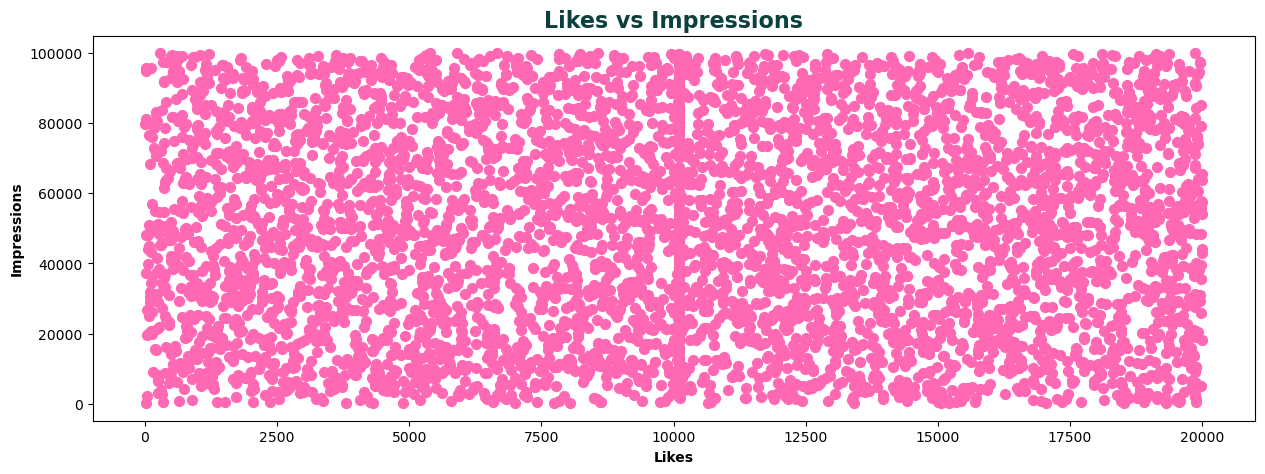

In [ ]:
plt.figure(figsize=(15,5))
plt.scatter(df["likes"], df["impression_count"],marker="o",s=50,color="hotpink")
plt.xlabel("Likes",fontweight = "bold")
plt.ylabel("Impressions",fontweight = "bold")
plt.title("Likes vs Impressions",fontsize=16, fontweight="bold", color="#0b403f")
plt.show()

In [ ]:
# Line: daily engagement trend

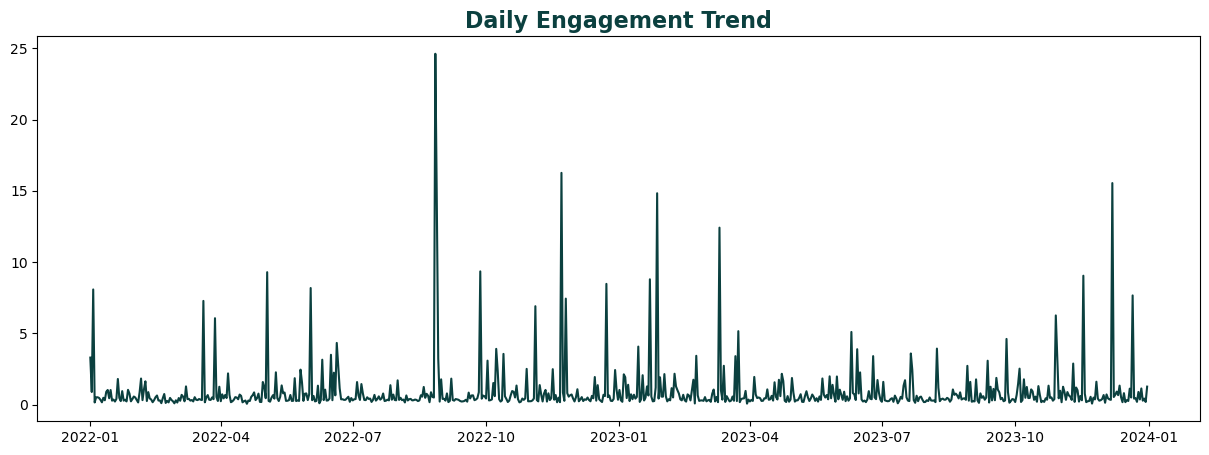

In [ ]:
plt.figure(figsize=(15,5))
daily = df.groupby('posted_at')['engagement_rate'].mean()
plt.plot(daily,color = "#0b403f")
plt.title("Daily Engagement Trend",fontsize=16, fontweight="bold", color="#0b403f")
plt.show()

In [ ]:
# Bar: posts by category

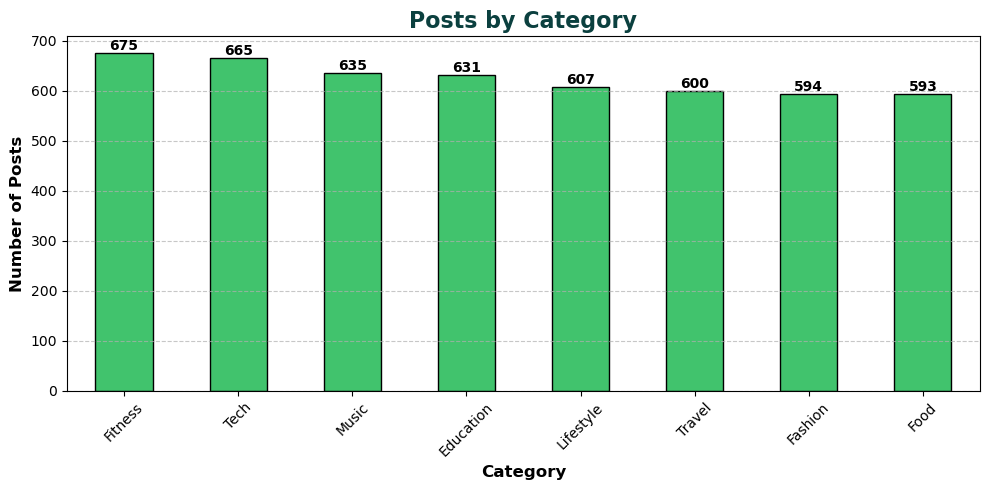

In [ ]:
plt.figure(figsize=(10,5))
Bar = df["post_category"].value_counts().plot(kind="bar",color="#41c36d",
    edgecolor="black")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.title("Posts by Category", fontsize=16, fontweight="bold", color="#0b403f")
plt.xlabel("Category", fontsize=12, fontweight="bold")
plt.ylabel("Number of Posts", fontsize=12, fontweight="bold")
# Add data labels
for container in Bar.containers:
    Bar.bar_label(container, label_type="edge", fontweight = "bold")
plt.tight_layout()
plt.show()

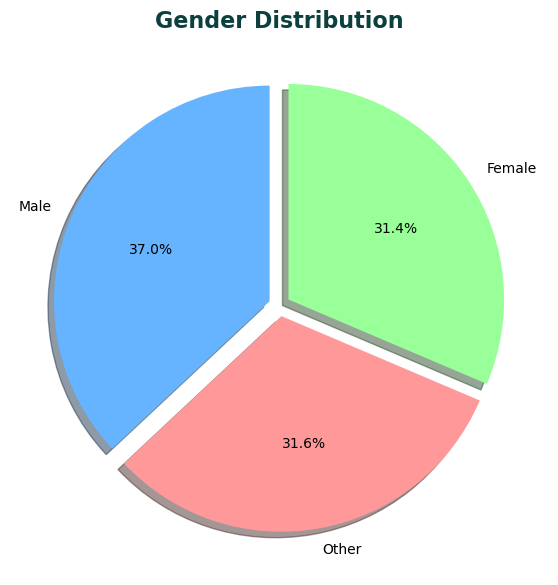

In [ ]:
plt.figure(figsize=(7,7))
df["gender"].value_counts().plot(
    kind="pie",
    autopct='%1.1f%%',
    startangle=90,
    colors=["#66b3ff","#ff9999","#99ff99","#ffcc99"],
    explode=[0.05]*len(df["gender"].value_counts()),
    shadow=True
)
plt.ylabel("")
plt.title("Gender Distribution", fontsize=16, fontweight="bold", color="#0b403f")
plt.show()

In [ ]:
# Histogram: age

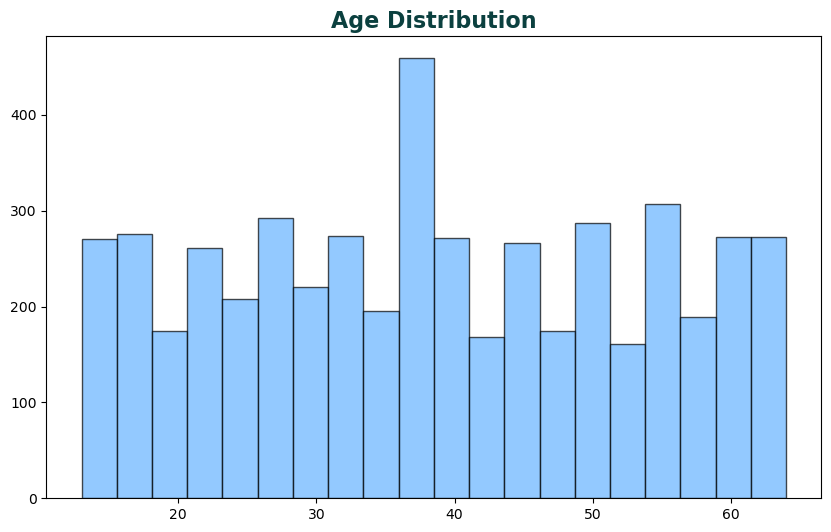

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(
    df["age"],
    bins=20,
    color="#66b3ff",
    edgecolor="black",
    alpha=0.7
)
plt.title("Age Distribution", fontsize=16, fontweight="bold", color="#0b403f")
plt.show()

In [ ]:
# Box: engagement rate

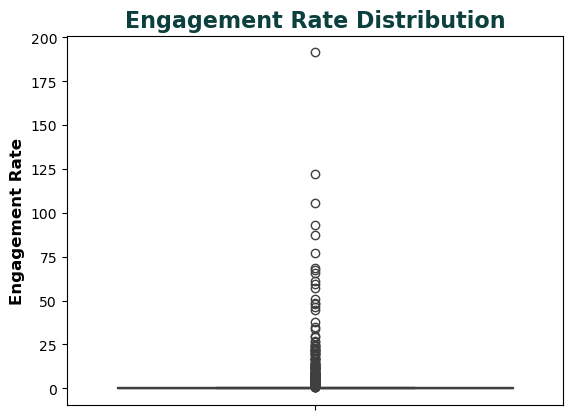

In [ ]:
sns.boxplot(y=df["engagement_rate"])
plt.title("Engagement Rate Distribution", fontsize=16, fontweight="bold", color="#0b403f")
plt.ylabel("Engagement Rate", fontsize=12, fontweight="bold")
plt.show()

######  	Seaborn

In [ ]:
#  	Count plot: post type

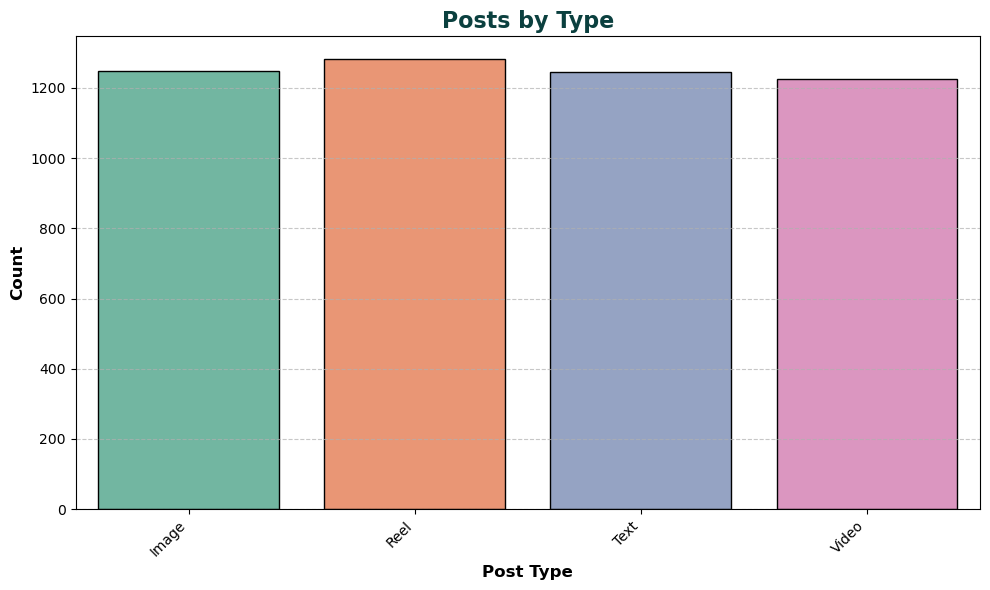

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(
    x="post_type",
    data=df,
    palette="Set2",
    edgecolor="black"
)
plt.title("Posts by Type", fontsize=16, fontweight="bold", color="#0b403f")
plt.xlabel("Post Type", fontsize=12, fontweight="bold")
plt.ylabel("Count", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#  Bar plot: avg likes by category

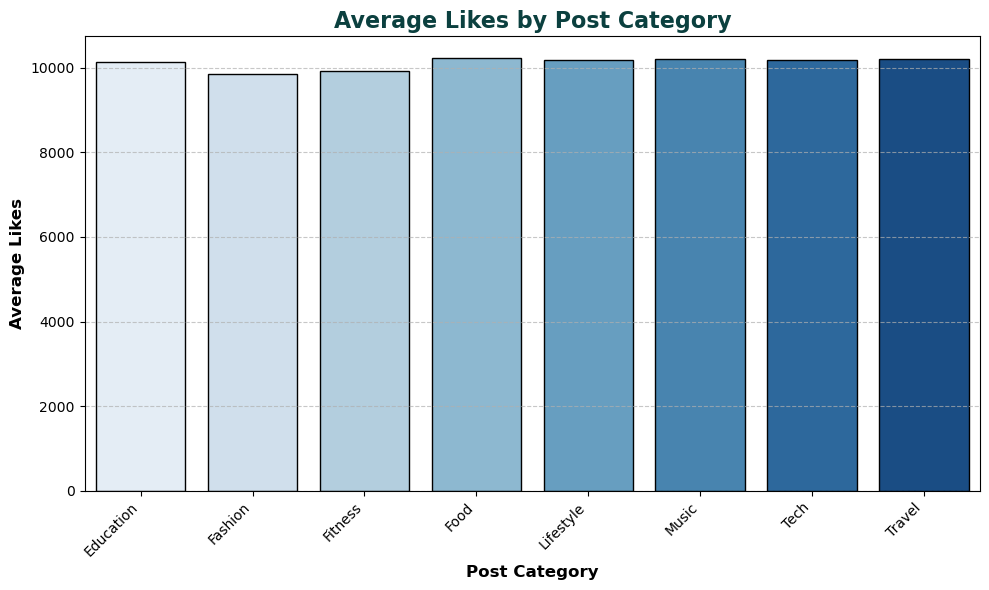

In [ ]:
avg_likes = df.groupby("post_category")["likes"].mean()
plt.figure(figsize=(10,6))
sns.barplot(
    x=avg_likes.index,
    y=avg_likes.values,
    palette="Blues",
    edgecolor="black"
)
plt.title("Average Likes by Post Category", fontsize=16, fontweight="bold", color="#0b403f")
plt.xlabel("Post Category", fontsize=12, fontweight="bold")
plt.ylabel("Average Likes", fontsize=12, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
# Violin: followers vs sentiment

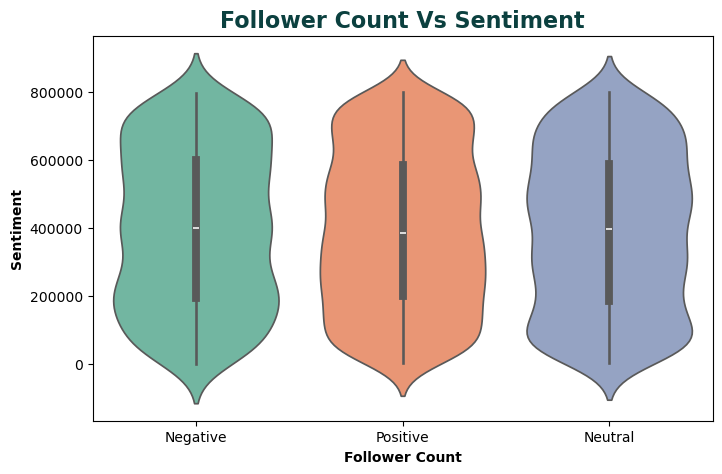

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(y="follower_count",x="sentiment",data=df,inner="box",palette="Set2")
plt.title("Follower Count Vs Sentiment",fontsize=16, fontweight="bold", color="#0b403f")
plt.xlabel("Follower Count",fontweight="bold")
plt.ylabel("Sentiment",fontweight="bold")
plt.show()

In [ ]:
#  Pair plot: numeric features

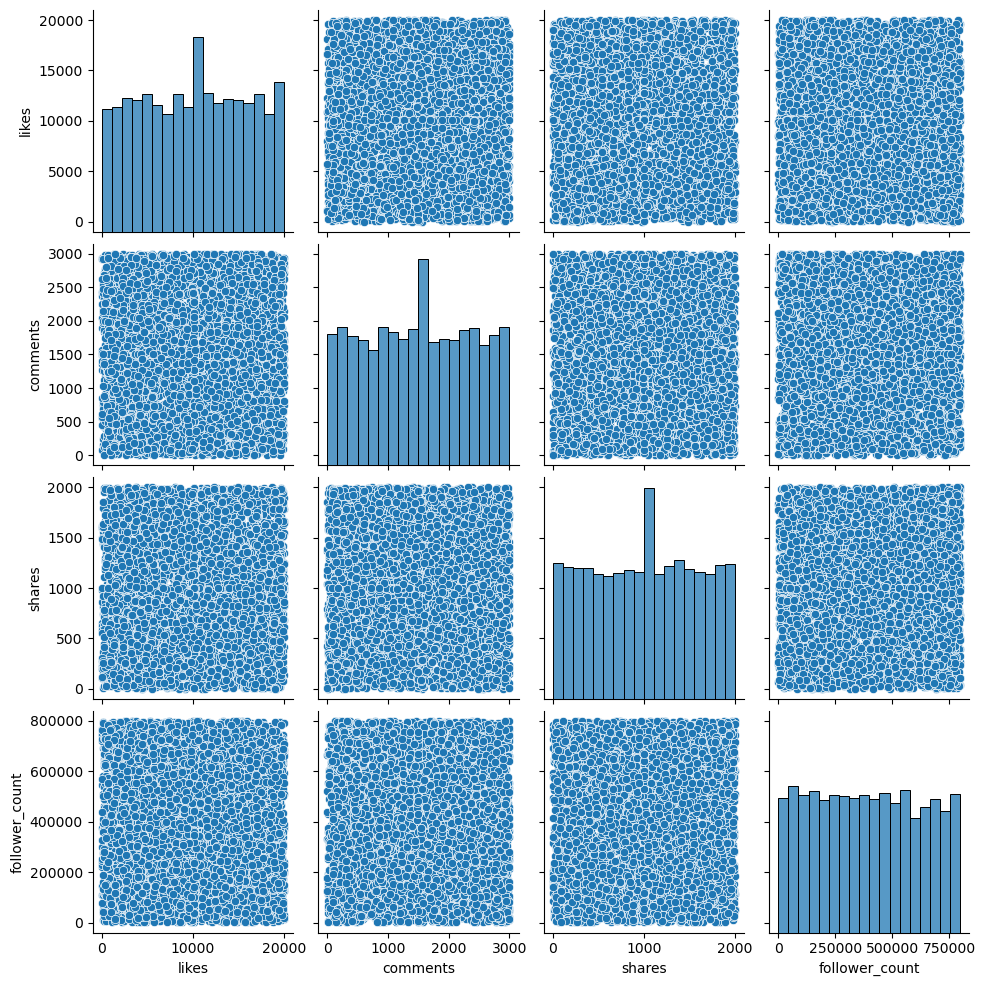

In [ ]:
sns.pairplot(df[['likes','comments','shares','follower_count']])
plt.show()

In [ ]:
# 	Heatmap: correlation matrix

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f",
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap", fontsize=18, fontweight="bold", color="#0b403f")
plt.xticks(rotation=45, ha="right", fontsize=10, fontweight="bold")
plt.yticks(rotation=0, fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
#  Swarm plot: engagement vs device

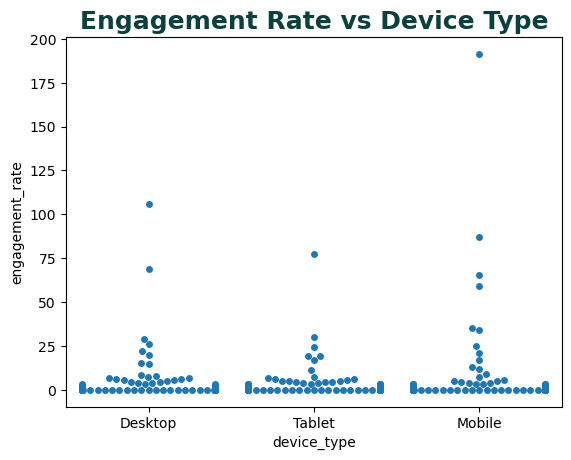

In [ ]:
sample_df = df.sample(2000)
sns.swarmplot(data=sample_df, x='device_type', y='engagement_rate')
plt.title("Engagement Rate vs Device Type", fontsize=18, fontweight="bold", color="#0b403f")
plt.show()

###### 	Plotly

In [ ]:
# Interactive line chart/bar chart/bubble/scatter chart


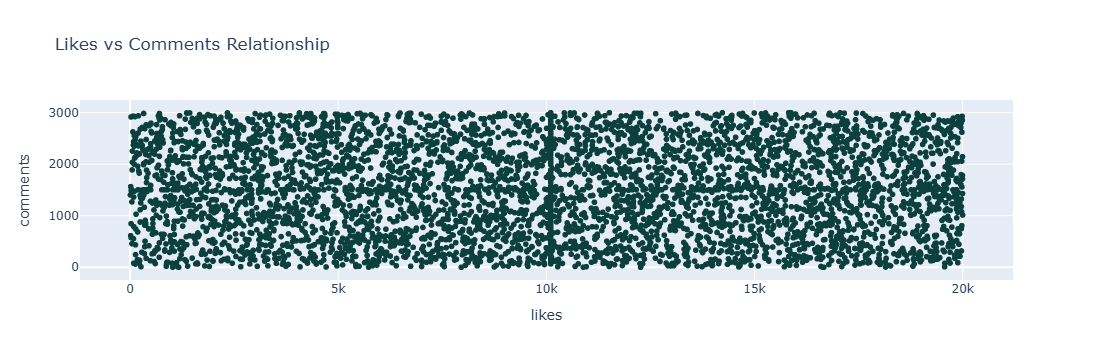

In [ ]:
sca = px.scatter(df, x='likes', y='comments', title='Likes vs Comments Relationship',color_discrete_sequence=["#0b403f"])
sca.show()

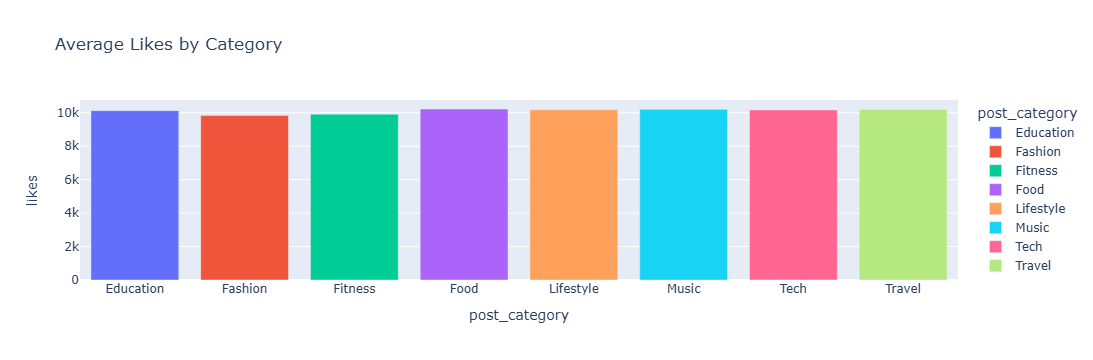

In [ ]:
avg_likes = df.groupby("post_category")["likes"].mean().reset_index()

Bar = px.bar(
    avg_likes,
    x="post_category",
    y="likes",
    title="Average Likes by Category",
    color="post_category"
)

Bar.show()

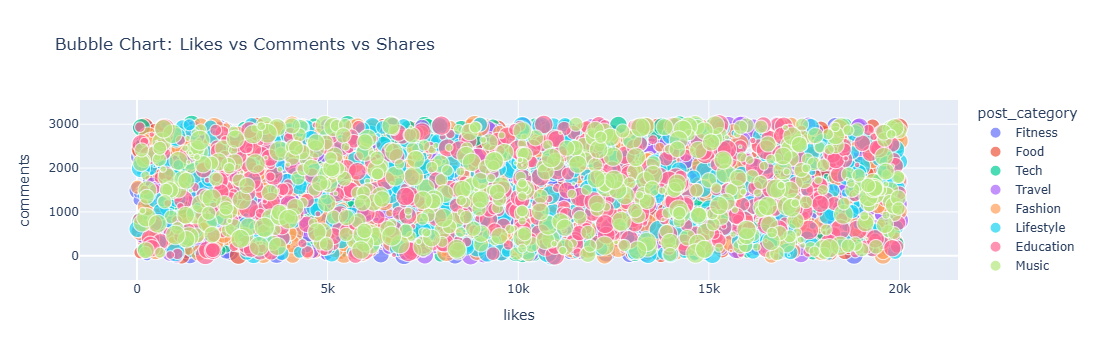

In [ ]:
Bub = px.scatter(
    df,
    x="likes",
    y="comments",
    size="shares",
    color="post_category",
    hover_name="country",
    title="Bubble Chart: Likes vs Comments vs Shares"
)

Bun.show()

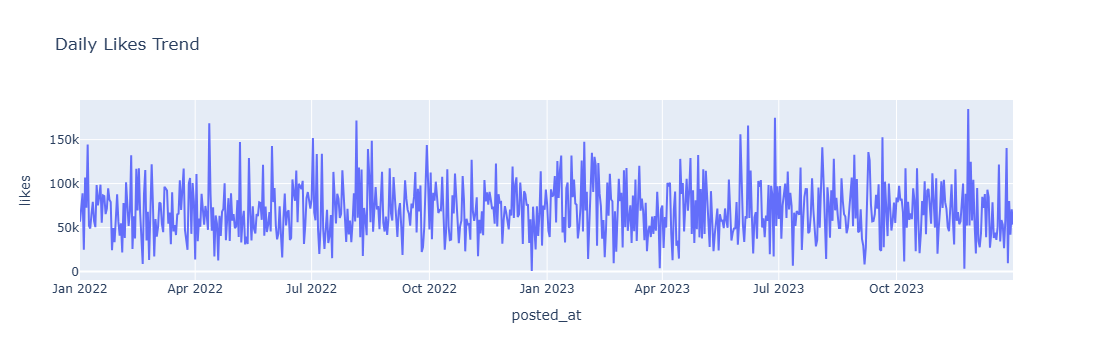

In [ ]:
df['posted_at'] = pd.to_datetime(df['posted_at'])

daily_engagement = df.groupby(df['posted_at'].dt.date)['likes'].sum().reset_index()

lin = px.line(
    daily_engagement,
    x='posted_at',
    y='likes',
    title="Daily Likes Trend"
)

lin.show()

#### ❖	Final Insights should include the following analysis

##### Content Performance

In [ ]:
# Which post types have the highest engagement
post_type_engagement = df.groupby("post_type")["engagement_rate"].sum().sort_values(ascending=False)
post_type_engagement.head(1)

post_type
Video    1374.897126
Name: engagement_rate, dtype: float64

In [ ]:
post_type_engagement

post_type
Video    1374.897126
Text     1325.363965
Image    1116.870317
Reel     1004.648738
Name: engagement_rate, dtype: float64

In [ ]:
#Visualization

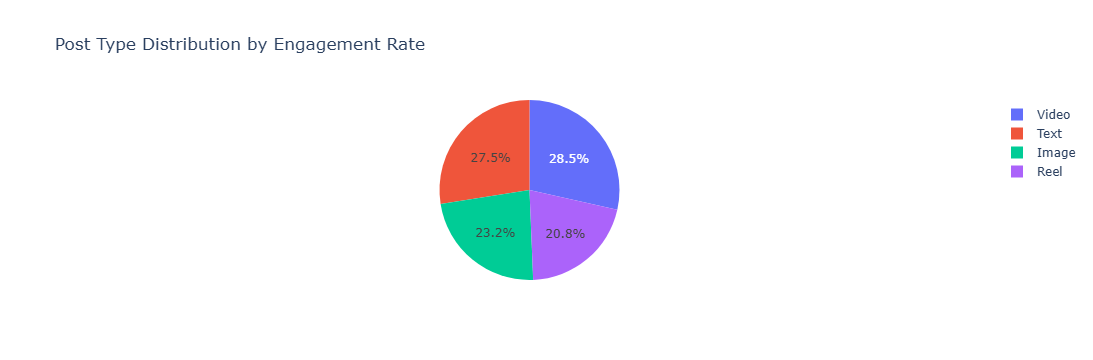

In [ ]:
post_type_engagement = df.groupby("post_type")["engagement_rate"].sum().sort_values(ascending=False)
pie_chart = px.pie(
    names=post_type_engagement.index,
    values=post_type_engagement.values,
    title="Post Type Distribution by Engagement Rate"
)

pie_chart.show()

### Insight:

##### Video posts have the highest engagement (~28.5%), indicating that video content attracts more user interaction.

##### Text posts contribute around 27.5%, showing that informative or story-based content still performs well.

##### Image posts account for ~23.2%, suggesting moderate engagement compared to video.

##### Reels have the lowest share (~20.8%), meaning they generate comparatively lower engagement in this dataset.

### Conclusion:
##### Video content is the most effective format for driving engagement.

In [ ]:
# Best-performing content category?
performe_category_engagement = df.groupby('post_category')['engagement_rate'].sum().sort_values(ascending=False)
performe_category_engagement.head(3)

post_category
Food         805.666287
Tech         771.716085
Lifestyle    662.248529
Name: engagement_rate, dtype: float64

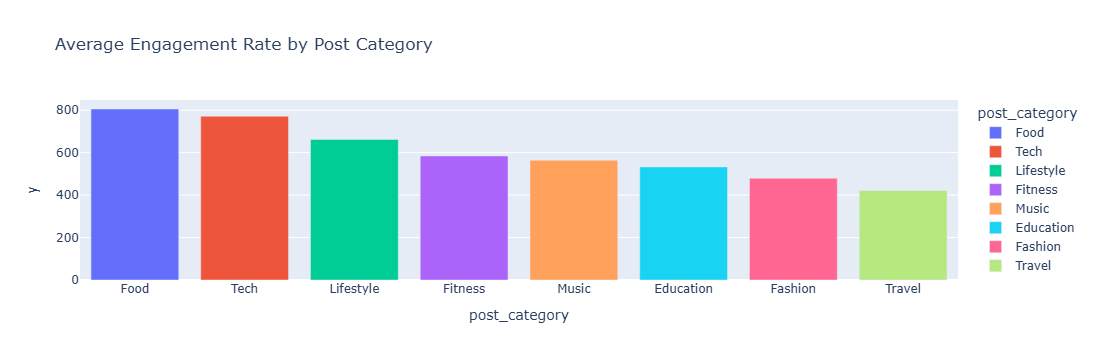

In [ ]:
#Visualization
Bar = px.bar(
    performe_category_engagement,
    x=performe_category_engagement.index,
    y=performe_category_engagement.values,
    title="Average Engagement Rate by Post Category",
    color=performe_category_engagement.index
)
Bar.show()

### Insight:

##### Food posts show the highest engagement, meaning audiences interact more with food-related content.

##### Tech and Lifestyle categories also perform strongly, indicating high audience interest.

##### Fitness and Music show moderate engagement.

##### Travel has the lowest engagement rate, suggesting it may require better content strategy.

### Conclusion:
##### Food, Tech, and Lifestyle are the top-performing categories.

In [ ]:
# Which countries have the highest average engagement rate?
country_engagement = df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False)
top10  = country_engagement.head(10).reset_index()
top10

,country,engagement_rate
0,Brazil,1.540704
1,Australia,1.324339
2,France,1.146402
3,Uae,1.112352
4,Canada,0.916659
5,Uk,0.850966
6,Japan,0.769623
7,Germany,0.759000
8,India,0.655005
9,Usa,0.576580


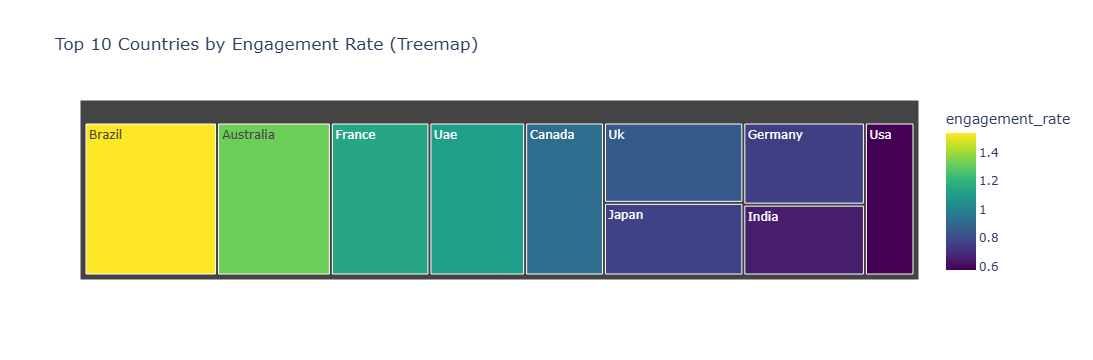

In [ ]:
#Visualization
tree_map = px.treemap(
    top10,
    path=['country'],
    values='engagement_rate',
    color='engagement_rate',
    color_continuous_scale='Viridis',
    title='Top 10 Countries by Engagement Rate (Treemap)'
)

tree_map.show()

### Insight:

##### Brazil has the highest engagement rate among all countries.

##### Australia and France also show strong engagement levels.

##### USA and India appear to have comparatively lower engagement.

### Conclusion:
##### Engagement varies by region, with Brazil leading audience interaction.

##### User Trends

In [ ]:
# How age affects engagement
age_affects_engagement = df.groupby(df["age"])["engagement_rate"].sum()
age_affects_engagement.head()

age
13     37.357834
14    102.312829
15     61.418601
16    107.962583
17     77.288661
Name: engagement_rate, dtype: float64

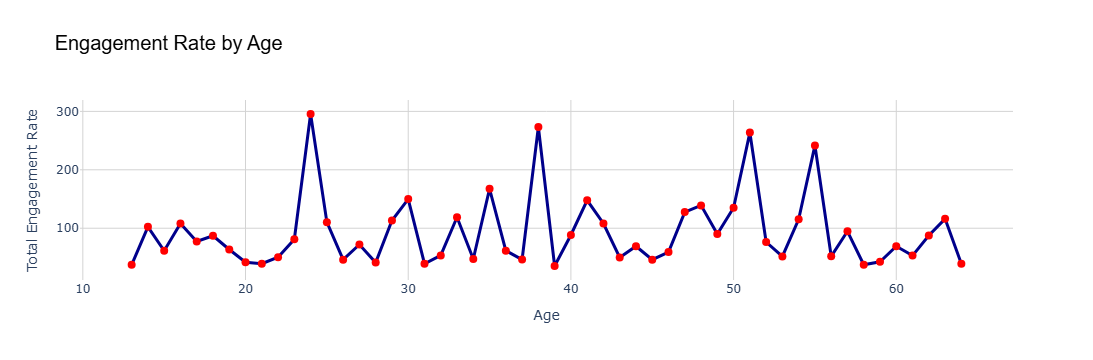

In [ ]:
#Visualization
lin = px.line(
    x=age_affects_engagement.index,
    y=age_affects_engagement.values,
    markers=True,
    title="Engagement Rate by Age"
)
# Customize layout
lin.update_layout(
    title=dict(
        text="Engagement Rate by Age",
        font=dict(size=20, family="Arial", color="black")
    ),
    xaxis_title="Age",
    yaxis_title="Total Engagement Rate",
    plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="lightgrey"),
    yaxis=dict(showgrid=True, gridcolor="lightgrey")
)
# Customize line style
lin.update_traces(
    line=dict(color="darkblue", width=3, dash="solid"),
    marker=dict(size=8, color="red", symbol="circle")
)
lin.show()


### Insight:

##### Engagement fluctuates across different age groups.

##### Peak engagement appears around ages 24, 38, and 52.

##### Lower engagement occurs in late teens and early 60s.

### Conclusion:
##### Users in the mid-age range tend to interact more with content.

In [ ]:
# Performance difference for verified accounts
verified_engagement = df.groupby('is_verified')['engagement_rate'].mean()
Acc_Eng_Rate = verified_engagement.reset_index()
Acc_Eng_Rate

,is_verified,engagement_rate
0,False,0.954744
1,True,1.054250


#####  Behavioral Insights

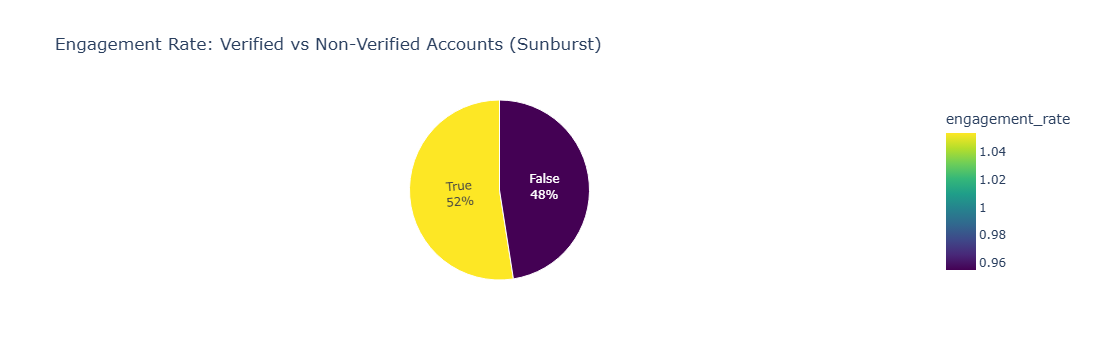

In [ ]:
#Visualization
fig = px.sunburst(
    Acc_Eng_Rate,
    path=['is_verified'],              # hierarchy levels
    values='engagement_rate',      # slice size
    color='engagement_rate',       # color by engagement rate
    color_continuous_scale='Viridis',
    title="Engagement Rate: Verified vs Non-Verified Accounts (Sunburst)"
)
fig.update_traces(textinfo="label+percent entry")
fig.update_traces(rotation=90)
fig.show()

### Insight:

#####  Verified accounts contribute around 52% of engagement.

##### Non-verified accounts contribute about 48%.

### Conclusion:
##### Verified accounts slightly outperform non-verified accounts in engagement.

In [ ]:
#	Best time of day for impressions
# extract hour
df["hour"] = df["posted_at"].dt.second
# find best time for impressions
hourly_impressions  = df.groupby("hour")["impression_count"].mean().reset_index()
best_time = hourly_impressions.loc[hourly_impressions['impression_count'].idxmax()]
print(best_time)


hour                    0.0000
impression_count    50013.7328
Name: 0, dtype: float64


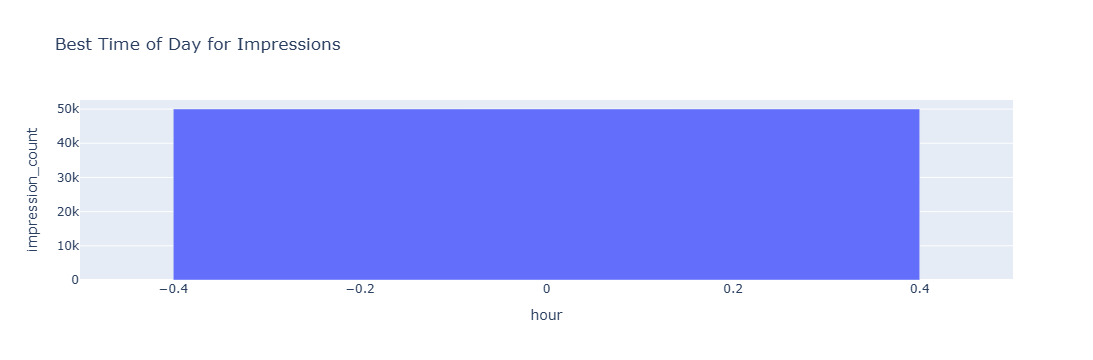

In [ ]:
#Visualization
fig = px.bar(
    hourly_impressions,
    x="hour",
    y="impression_count",
    title="Best Time of Day for Impressions"
)
fig.show()

### Insight:

##### The chart suggests that impressions reach around 50k during peak hours.

##### This indicates that there is a specific time window when content visibility is highest.

### Conclusion:
##### Posting during peak hours significantly increases impressions.

In [ ]:
# Device type impact on watch time
device_watchtime = df.groupby("device_type")["watch_time_sec"].mean().reset_index()
print(device_watchtime)

  device_type  watch_time_sec
0     Desktop     3974.792521
1      Mobile     4087.830760
2      Tablet     3979.736429


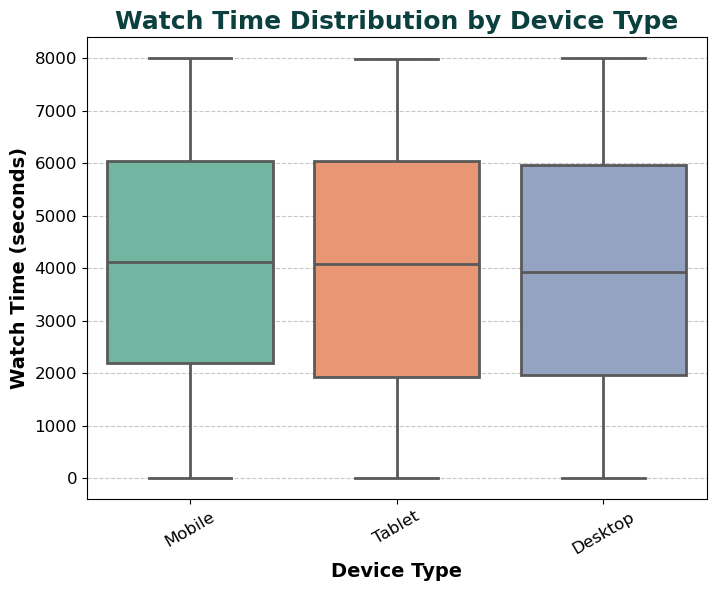

In [ ]:
#Visualization
plt.figure(figsize=(8,6))
sns.boxplot(
    x="device_type",
    y="watch_time_sec",
    data=df,
    palette="Set2",
    linewidth=2,
    fliersize=4
)
# Add title and axis labels with custom fonts
plt.title("Watch Time Distribution by Device Type",
          fontsize=18, fontweight="bold", color="#0b403f")
plt.xlabel("Device Type", fontsize=14, fontweight="bold")
plt.ylabel("Watch Time (seconds)", fontsize=14, fontweight="bold")
# Rotate x-axis labels if needed
plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)
# Add grid for readability
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


### Insight:

##### Mobile devices show the highest watch time distribution.

##### Tablet and Desktop have similar but slightly lower watch time.

##### The median watch time across devices is around 4000 seconds.

### Conclusion:
##### Mobile users consume the most content.

##### Sentiment Analysis

In [ ]:
# Which sentiment performs best
sentiment_performance = df.groupby("sentiment")['engagement_rate'].mean()
print(sentiment_performance)

sentiment
Negative    1.038486
Neutral     0.991170
Positive    0.919744
Name: engagement_rate, dtype: float64


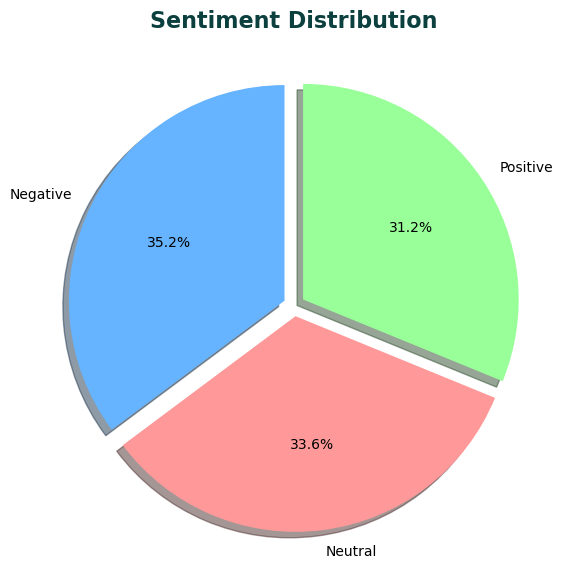

In [ ]:
#Visualization
plt.figure(figsize=(7,7))
sentiment_performance.plot(
    kind="pie",
    autopct='%1.1f%%',
    startangle=90,
    colors=["#66b3ff","#ff9999","#99ff99","#ffcc99"],
    explode=[0.05]*len(sentiment_performance),
    shadow=True
)
plt.ylabel("")
plt.title("Sentiment Distribution", fontsize=16, fontweight="bold", color="#0b403f")
plt.show()

### Insight:

##### Negative sentiment: ~35.2% (highest)

##### Neutral sentiment: ~33.6%

##### Positive sentiment: ~31.2%

### Conclusion:
##### Negative sentiment slightly dominates audience responses.

In [ ]:
#Behavior of negative/neutral sentiment posts
negative_neutral = df[df['sentiment'].isin(['negative','neutral'])] \
                    .groupby('sentiment')['engagement_rate'].mean()

negative_neutral

sentiment
negative    1.038486
neutral     0.991170
Name: engagement_rate, dtype: float64

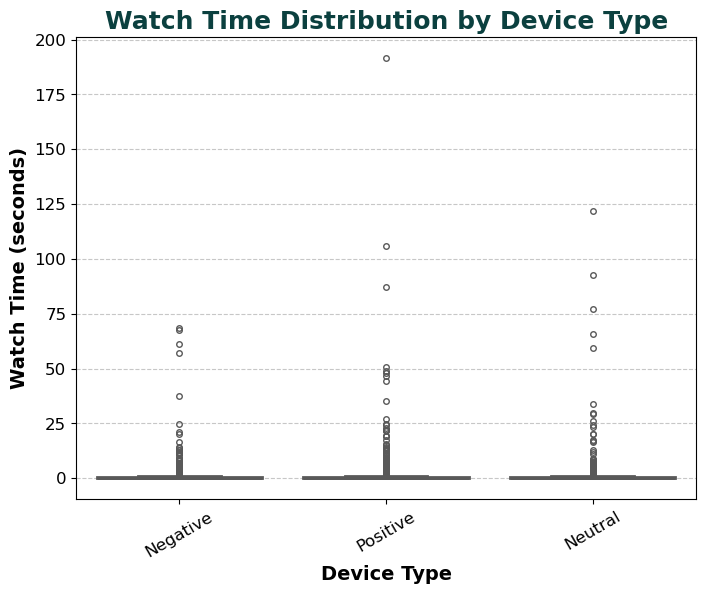

In [ ]:
#Visualization
plt.figure(figsize=(8,6))
sns.boxplot(
    x="sentiment",
    y="engagement_rate",
    data=df,
    palette="Set2",
    linewidth=2,
    fliersize=4
)
# Add title and axis labels with custom fonts
plt.title("Watch Time Distribution by Device Type",
          fontsize=18, fontweight="bold", color="#0b403f")
plt.xlabel("Device Type", fontsize=14, fontweight="bold")
plt.ylabel("Watch Time (seconds)", fontsize=14, fontweight="bold")
# Rotate x-axis labels if needed
plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)
# Add grid for readability
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

### Insight:

##### Positive sentiment shows some of the highest watch time values.

##### Negative and neutral sentiments mostly show lower watch time ranges.

##### There are several outliers indicating highly engaged viewers.

### Conclusion:
##### Positive content tends to retain viewers longer.

# Overall Key Insights:

##### Video posts generate the highest engagement.

##### Food and Tech categories perform best.

##### Brazil shows the highest engagement geographically.

##### Middle-aged users interact more with content.

##### Mobile devices dominate content consumption.

##### Positive content leads to higher watch time.